# Proyek Akhir: Menyelesaikan Permasalahan Institusi Pendidikan
## Jaya Jaya Institut — Sistem Deteksi Dini Risiko Dropout Mahasiswa

- **Nama:** *Tegar Arifin Prasetyo*
- **Email:** *arifintegar12@gmail.com*
- **ID Dicoding:** *tegar_arifin_umpr*

**Versi Python:** 3.12.3

---

## 1. Business Understanding

Jaya Jaya Institut merupakan salah satu institusi pendidikan perguruan tinggi yang telah berdiri
sejak tahun 2000. Hingga saat ini institusi tersebut telah mencetak banyak lulusan dengan reputasi
yang sangat baik. Akan tetapi, terdapat banyak juga siswa yang tidak menyelesaikan pendidikannya
alias **dropout**.

Jumlah dropout yang tinggi tentunya menjadi salah satu masalah yang besar untuk sebuah institusi
pendidikan. Mahasiswa kehilangan waktu, biaya, dan peluang karier tanpa memperoleh gelar,
sementara institusi kehilangan pendapatan operasional, mengalami penurunan tingkat kelulusan, dan
berisiko turun peringkat akreditasi. Oleh karena itu, Jaya Jaya Institut ingin **mendeteksi
secepat mungkin siswa yang mungkin akan melakukan dropout** sehingga dapat diberi bimbingan
khusus. Selain itu, institusi juga membutuhkan **dashboard** agar mudah dalam memahami data dan
memonitor performa siswa.

### 1.1 Permasalahan Bisnis

1. **Skala dan sebaran masalah belum terpetakan.** Institusi belum mengetahui program studi,
   jalur masuk, kelompok usia, atau kondisi finansial mana yang menjadi konsentrasi masalah
   dropout, sehingga alokasi sumber daya bimbingan tidak tepat sasaran.
2. **Faktor penyebab dropout belum teridentifikasi.** Belum diketahui variabel apa yang paling
   menentukan seorang mahasiswa akan dropout, sehingga intervensi yang diberikan bersifat
   coba-coba.
3. **Tidak ada mekanisme deteksi dini.** Institusi baru mengetahui seorang mahasiswa dropout
   setelah kejadiannya berlangsung, sehingga bimbingan khusus selalu terlambat diberikan.
4. **Tidak ada alat monitoring bagi manajemen.** Data mahasiswa tersimpan dalam bentuk mentah dan
   sulit dipahami oleh pihak non-teknis, sehingga pengambilan keputusan belum berbasis data.

### 1.2 Cakupan Proyek

1. Data understanding dan exploratory data analysis (EDA).
2. Data preparation: penyaringan kohort, perumusan target biner, encoding, dan scaling.
3. Modeling: membandingkan tiga algoritma klasifikasi.
4. Evaluation: pemilihan model terbaik, penyetelan *threshold*, dan analisis feature importance.
5. Membangun **business dashboard** untuk monitoring performa siswa.
6. Men-*deploy* **prototype machine learning** berbasis Streamlit ke Streamlit Community Cloud.
7. Menyusun **rekomendasi action items** bagi manajemen Jaya Jaya Institut.

### 1.3 Persiapan

**Sumber data:** [Students' Performance — Dicoding Academy](https://github.com/dicodingacademy/dicoding_dataset/tree/main/students_performance)

**Versi Python:** 3.12.3

**Setup environment:**

```bash
python -m venv venv
source venv/bin/activate      # Windows: venv\Scripts\activate
pip install -r requirements.txt
```

## 2. Data Understanding

In [ ]:
import warnings, json, os
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import sys

from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     cross_val_score, cross_val_predict)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                             average_precision_score, accuracy_score, precision_score,
                             recall_score, f1_score, roc_curve, precision_recall_curve)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

BLUE = "#2E86AB"        # warna tunggal untuk seluruh bar chart
ACCENT = "#E4572E"      # hanya dipakai bila memang perlu membedakan dua kelas
RANDOM_STATE = 42

print("Versi Python :", sys.version.split()[0])

Versi Python : 3.12.3


In [ ]:
URL = "https://raw.githubusercontent.com/dicodingacademy/dicoding_dataset/main/students_performance/data.csv"
try:
    df = pd.read_csv("data.csv", sep=";")
except FileNotFoundError:
    df = pd.read_csv(URL, sep=";")

df.columns = [c.strip().replace("\ufeff", "") for c in df.columns]
print("Dimensi dataset :", df.shape)
df.head()

Dimensi dataset : (4424, 37)


,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nacionality                                   4424 non-null   int64  
 8   Mothers_qualification                         4424 non-null   int64  
 9   Fathers_qualification                         4424 non-null   int64  
 10 

In [ ]:
print("Jumlah nilai kosong  :", df.isna().sum().sum())
print("Jumlah baris duplikat:", df.duplicated().sum())
print()
print("Distribusi kolom Status:")
print(df["Status"].value_counts())
print()
print((df["Status"].value_counts(normalize=True) * 100).round(2))

Jumlah nilai kosong  : 0
Jumlah baris duplikat: 0

Distribusi kolom Status:
Status
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

Status
Graduate    49.93
Dropout     32.12
Enrolled    17.95
Name: proportion, dtype: float64


Dataset terdiri atas **4.424 baris** dan **37 kolom**, **tanpa nilai kosong maupun duplikat**,
sehingga proses pembersihan data relatif ringan. Kolom target `Status` memiliki tiga kelas:
`Graduate` (2.209), `Dropout` (1.421), dan `Enrolled` (794).

### Deskripsi Fitur

| Kelompok | Fitur | Keterangan |
|---|---|---|
| Demografi | `Marital_status`, `Gender`, `Age_at_enrollment`, `Nacionality`, `International`, `Displaced` | Karakteristik pribadi mahasiswa |
| Latar belakang keluarga | `Mothers_qualification`, `Fathers_qualification`, `Mothers_occupation`, `Fathers_occupation` | Pendidikan & pekerjaan orang tua |
| Pendaftaran | `Application_mode`, `Application_order`, `Course`, `Daytime_evening_attendance`, `Previous_qualification`, `Previous_qualification_grade`, `Admission_grade` | Jalur & kualifikasi saat masuk |
| Finansial | `Debtor`, `Tuition_fees_up_to_date`, `Scholarship_holder` | Kondisi keuangan mahasiswa |
| Akademik | `Curricular_units_1st/2nd_sem_*` (credited, enrolled, evaluations, approved, grade, without_evaluations) | Performa dua semester pertama |
| Makroekonomi | `Unemployment_rate`, `Inflation_rate`, `GDP` | Kondisi ekonomi saat studi berlangsung |

## 3. Data Preparation

### 3.1 Penyaringan Kohort — Dropout vs Graduate

Tujuan model adalah memprediksi apakah seorang mahasiswa akan **Dropout** atau **Graduate**.
Karena itu, hanya mahasiswa yang **telah menyelesaikan masa studinya** yang boleh dilibatkan
dalam proses training.

Mahasiswa berstatus `Enrolled` **tidak diikutsertakan** dalam training, dengan alasan:

1. `Enrolled` adalah status **sementara** — mahasiswa masih berjalan dan hasil akhirnya belum
   diketahui. Menggabungkannya dengan `Graduate` menjadi label 0 akan membuat target **ambigu**,
   karena sebagian dari mereka sesungguhnya akan dropout di kemudian hari. Label yang salah
   seperti ini menurunkan validitas model.
2. Kelompok `Enrolled` justru merupakan **populasi sasaran** sistem ini. Mereka disimpan terpisah
   dan dipakai sebagai data yang **diprediksi** oleh model, bukan data yang melatih model.

Target biner dirumuskan sebagai: **`Dropout` = 1** dan **`Graduate` = 0**.

In [ ]:
# Kohort untuk pemodelan: hanya mahasiswa yang telah menyelesaikan masa studi
model_df = df[df["Status"].isin(["Dropout", "Graduate"])].copy()

# Kohort mahasiswa aktif: disimpan terpisah, hanya untuk prediksi di masa mendatang
enrolled_df = df[df["Status"] == "Enrolled"].copy()

# Target biner: 1 = Dropout, 0 = Graduate
model_df["Dropout"] = (model_df["Status"] == "Dropout").astype(int)

print(f"Dataset penuh                  : {len(df)} baris")
print(f"Kohort pemodelan (Dropout+Grad): {len(model_df)} baris")
print(f"Kohort Enrolled (disimpan)     : {len(enrolled_df)} baris")

Dataset penuh                  : 4424 baris
Kohort pemodelan (Dropout+Grad): 3630 baris
Kohort Enrolled (disimpan)     : 794 baris


              Jumlah  Persentase (%)
Graduate (0)    2209           60.85
Dropout (1)     1421           39.15

Rasio ketidakseimbangan: 1 : 1.55


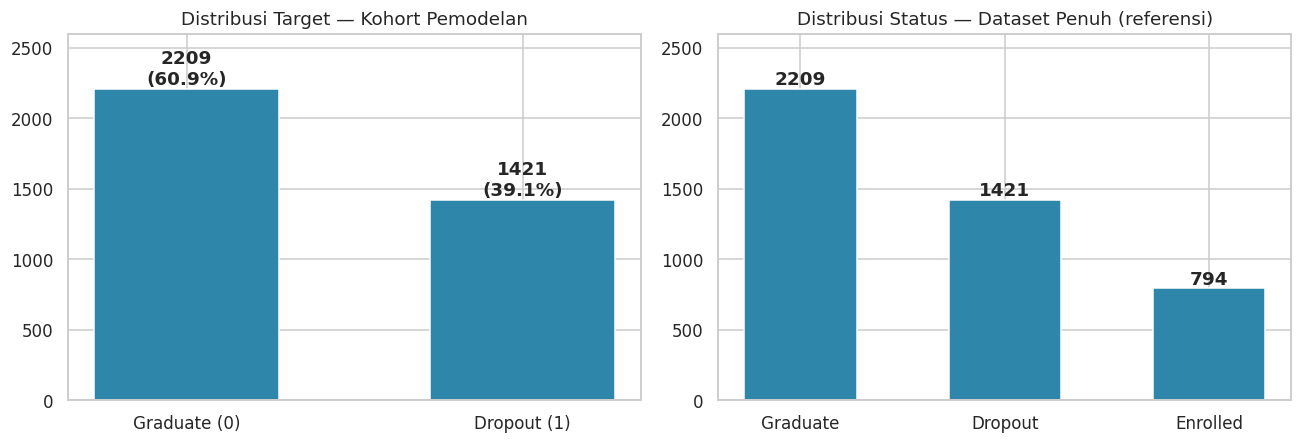

In [ ]:
# Verifikasi distribusi target
counts = model_df["Dropout"].value_counts().sort_index()
props = (model_df["Dropout"].value_counts(normalize=True).sort_index() * 100).round(2)
ringkasan = pd.DataFrame({"Jumlah": counts.values, "Persentase (%)": props.values},
                         index=["Graduate (0)", "Dropout (1)"])
print(ringkasan)
print()
print(f"Rasio ketidakseimbangan: 1 : {counts.loc[0] / counts.loc[1]:.2f}")

fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
ax[0].bar(["Graduate (0)", "Dropout (1)"], counts.values, color=BLUE, width=0.55)
for i, v in enumerate(counts.values):
    ax[0].text(i, v + 30, f"{v}\n({v/len(model_df)*100:.1f}%)", ha="center", fontweight="bold")
ax[0].set_title("Distribusi Target — Kohort Pemodelan"); ax[0].set_ylim(0, 2600)

full = df["Status"].value_counts()
ax[1].bar(full.index, full.values, color=BLUE, width=0.55)
for i, v in enumerate(full.values): ax[1].text(i, v + 30, f"{v}", ha="center", fontweight="bold")
ax[1].set_title("Distribusi Status — Dataset Penuh (referensi)"); ax[1].set_ylim(0, 2600)
plt.tight_layout(); plt.show()

**Verifikasi distribusi target.** Setelah penyaringan, kohort pemodelan berisi **3.630 mahasiswa**
dengan komposisi **Graduate 2.209 (60,9%)** dan **Dropout 1.421 (39,1%)**. Rasio
ketidakseimbangannya hanya **1 : 1,55** — tergolong seimbang dan cukup untuk membuat model belajar
dengan baik. Tidak diperlukan teknik *oversampling* seperti SMOTE; penggunaan
`class_weight="balanced"` dan penyetelan threshold sudah memadai.

In [ ]:
CAT = ["Marital_status", "Application_mode", "Course", "Daytime_evening_attendance",
       "Previous_qualification", "Nacionality", "Mothers_qualification", "Fathers_qualification",
       "Mothers_occupation", "Fathers_occupation", "Displaced", "Educational_special_needs",
       "Debtor", "Tuition_fees_up_to_date", "Gender", "Scholarship_holder", "International"]
NUM = [c for c in df.columns if c not in CAT + ["Status", "Dropout"]]

print(f"Fitur kategorikal : {len(CAT)}")
print(f"Fitur numerik     : {len(NUM)}")
print(f"Total fitur       : {len(CAT) + len(NUM)}")

Fitur kategorikal : 17
Fitur numerik     : 19
Total fitur       : 36


## 4. Exploratory Data Analysis

Seluruh EDA berikut dilakukan pada **kohort pemodelan** (3.630 mahasiswa Dropout + Graduate),
agar angka dropout rate yang dihitung bermakna dan konsisten dengan target model.

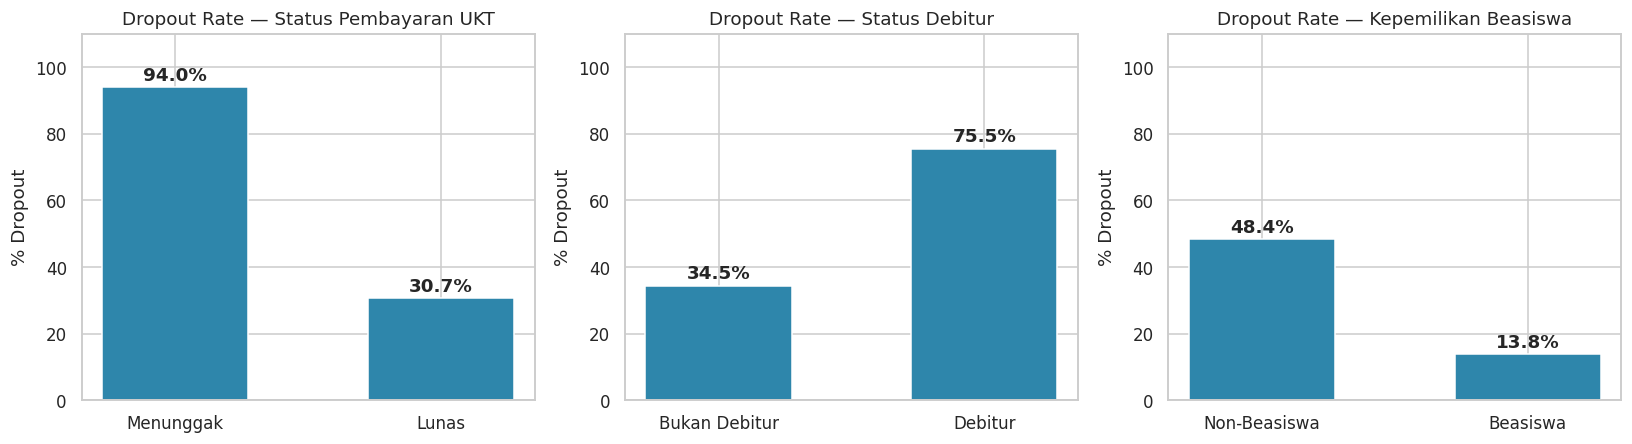

In [ ]:
fin = [("Tuition_fees_up_to_date", ["Menunggak", "Lunas"], "Status Pembayaran UKT"),
       ("Debtor", ["Bukan Debitur", "Debitur"], "Status Debitur"),
       ("Scholarship_holder", ["Non-Beasiswa", "Beasiswa"], "Kepemilikan Beasiswa")]

fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))
for i, (c, labs, title) in enumerate(fin):
    r = model_df.groupby(c)["Dropout"].mean() * 100
    ax[i].bar(labs, r.values, color=BLUE, width=0.55)
    for j, v in enumerate(r.values):
        ax[i].text(j, v + 2, f"{v:.1f}%", ha="center", fontweight="bold")
    ax[i].set_title(f"Dropout Rate — {title}"); ax[i].set_ylabel("% Dropout"); ax[i].set_ylim(0, 110)
plt.tight_layout(); plt.show()

**Insight — faktor finansial sangat dominan.**

- Mahasiswa yang **menunggak UKT** memiliki dropout rate **94,0%**, dibanding **30,7%** pada
  yang lunas. Selisihnya lebih dari 63 poin persentase.
- Mahasiswa berstatus **debitur** dropout pada tingkat **75,5%** vs **34,5%**.
- **Penerima beasiswa** jauh lebih aman: **13,8%** vs **48,4%**.

Ini menandakan bahwa masalah dropout di Jaya Jaya Institut bukan semata persoalan akademik,
melainkan sangat lekat dengan **kemampuan membayar**.

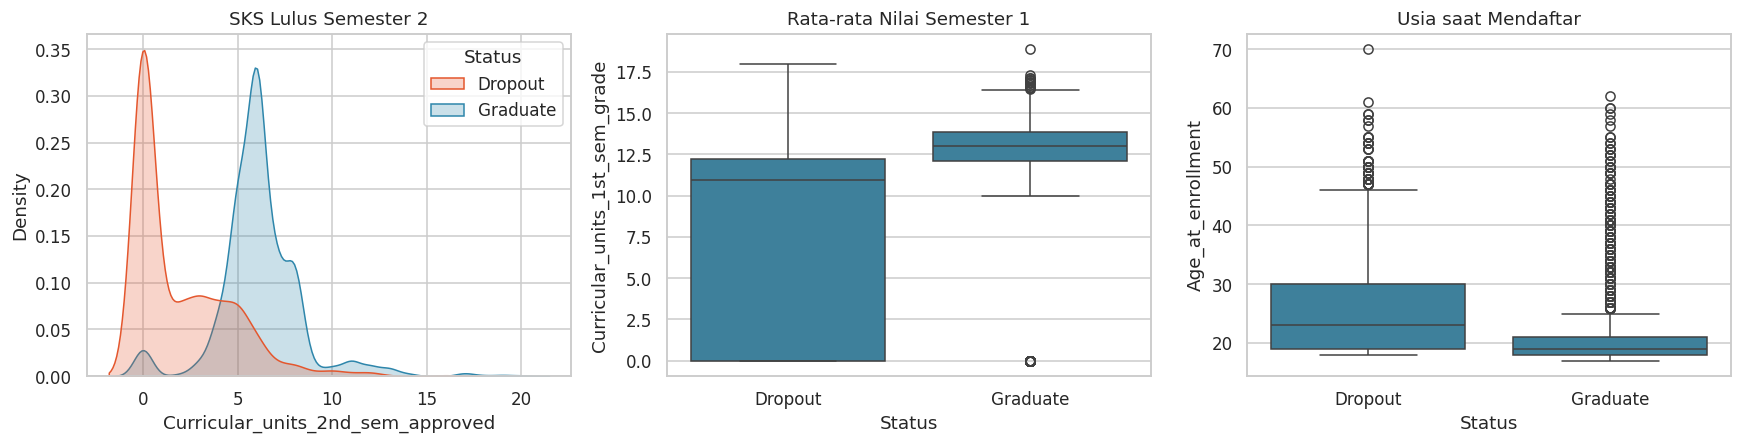

,Curricular_units_1st_sem_approved,Curricular_units_2nd_sem_approved,Curricular_units_1st_sem_grade,Curricular_units_2nd_sem_grade,Admission_grade,Age_at_enrollment
Status,,,,,,
Dropout,2.55,1.94,7.26,5.9,124.96,26.07
Graduate,6.23,6.18,12.64,12.7,128.79,21.78


In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))
sns.kdeplot(data=model_df, x="Curricular_units_2nd_sem_approved", hue="Status", fill=True,
            common_norm=False, palette={"Dropout": ACCENT, "Graduate": BLUE}, ax=ax[0])
ax[0].set_title("SKS Lulus Semester 2")

sns.boxplot(data=model_df, x="Status", y="Curricular_units_1st_sem_grade", color=BLUE, ax=ax[1])
ax[1].set_title("Rata-rata Nilai Semester 1")

sns.boxplot(data=model_df, x="Status", y="Age_at_enrollment", color=BLUE, ax=ax[2])
ax[2].set_title("Usia saat Mendaftar")
plt.tight_layout(); plt.show()

model_df.groupby("Status")[["Curricular_units_1st_sem_approved",
                            "Curricular_units_2nd_sem_approved",
                            "Curricular_units_1st_sem_grade",
                            "Curricular_units_2nd_sem_grade",
                            "Admission_grade", "Age_at_enrollment"]].mean().round(2)

**Insight — performa akademik dua semester pertama adalah sinyal paling awal.**

Mahasiswa dropout rata-rata hanya meluluskan **2,55 mata kuliah** di semester 1 dan **1,94** di
semester 2, dibandingkan lulusan yang meluluskan **6,23** dan **6,18**. Terlihat pula penumpukan
besar pada nilai 0 untuk kelompok dropout — indikasi mahasiswa yang berhenti aktif sejak awal.

Sebaliknya, nilai ujian masuk (`Admission_grade`) hanya berbeda tipis: **124,96** pada kelompok
dropout versus **128,79** pada lulusan. Artinya **kemampuan awal bukan penentu utama**; yang
menentukan adalah apa yang terjadi *setelah* mahasiswa masuk. Mahasiswa dropout juga rata-rata
mendaftar pada usia lebih tua (**26,07** vs **21,78** tahun).

,mean,count
Kategori_Performa,,
Kritis (<25%),90.5,796
Rendah (25-50%),98.7,236
Sedang (50-75%),67.7,378
Baik (>75%),9.5,2220


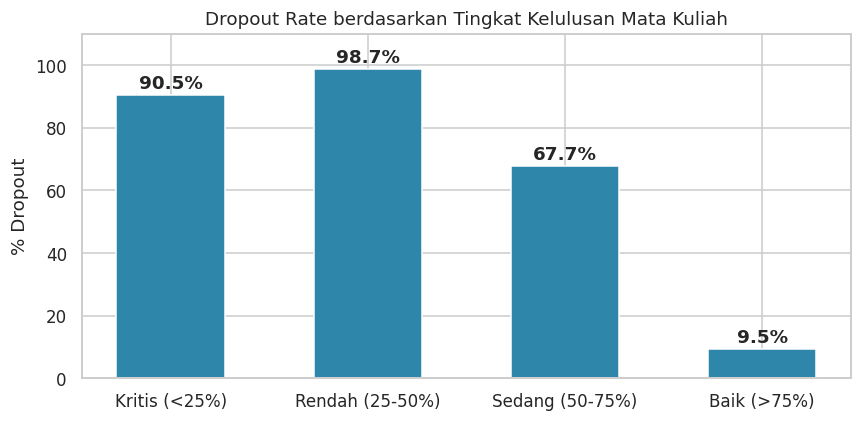

In [ ]:
tot = model_df["Curricular_units_1st_sem_enrolled"] + model_df["Curricular_units_2nd_sem_enrolled"]
apr = model_df["Curricular_units_1st_sem_approved"] + model_df["Curricular_units_2nd_sem_approved"]
model_df["Approval_Rate"] = np.where(tot > 0, apr / tot * 100, 0)
model_df["Kategori_Performa"] = pd.cut(model_df["Approval_Rate"], [-1, 25, 50, 75, 100],
                                       labels=["Kritis (<25%)", "Rendah (25-50%)",
                                               "Sedang (50-75%)", "Baik (>75%)"])

perf = model_df.groupby("Kategori_Performa", observed=True)["Dropout"].agg(["mean", "count"])
perf["mean"] = (perf["mean"] * 100).round(1)
display(perf)

plt.figure(figsize=(8, 4))
plt.bar(perf.index.astype(str), perf["mean"], color=BLUE, width=0.55)
for i, v in enumerate(perf["mean"]):
    plt.text(i, v + 2, f"{v}%", ha="center", fontweight="bold")
plt.title("Dropout Rate berdasarkan Tingkat Kelulusan Mata Kuliah")
plt.ylabel("% Dropout"); plt.ylim(0, 110); plt.tight_layout(); plt.show()

**Insight.** Tingkat kelulusan mata kuliah adalah pembeda paling tajam. Mahasiswa pada kategori
**Baik (>75%)** hanya dropout **9,5%**, sedangkan seluruh kategori di bawah 75% berada pada
tingkat yang jauh lebih tinggi — **Sedang 67,7%**, **Kritis 90,5%**, dan **Rendah 98,7%**.

Perlu dicatat bahwa kategori *Kritis* sedikit lebih rendah daripada *Rendah*. Penyebabnya,
kelompok *Kritis* juga menampung mahasiswa yang tidak mengambil mata kuliah sama sekali sehingga
tingkat kelulusannya tercatat 0 — sebagian di antaranya adalah kasus transfer kredit. Terlepas
dari itu, polanya jelas: **begitu tingkat kelulusan turun di bawah 75%, risiko dropout melonjak
drastis.** Ambang sederhana ini sudah dapat dipakai sebagai *rule of thumb* penyaringan oleh
dosen wali.

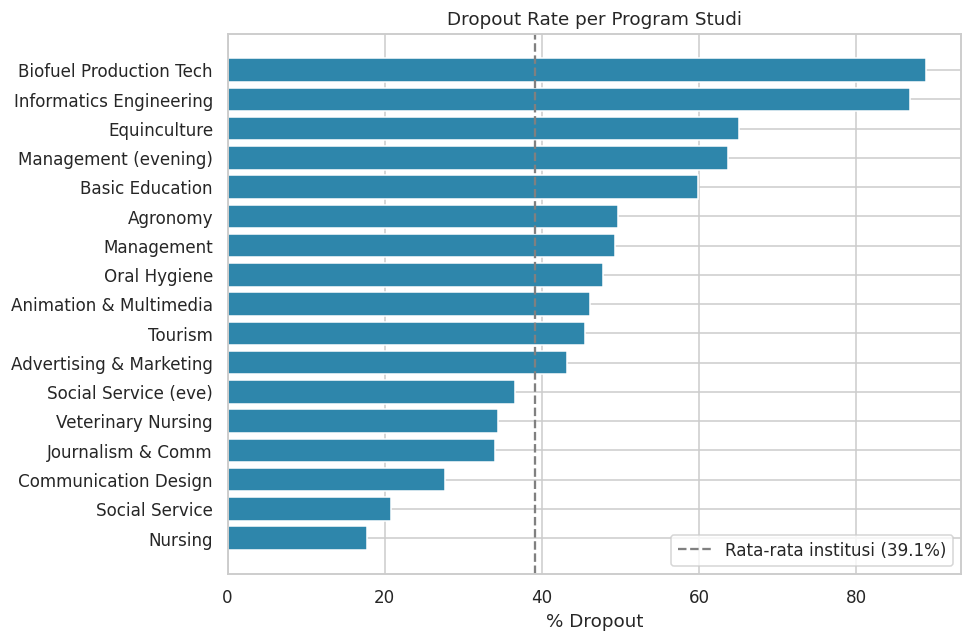

,mean,count
Program_Studi,,
Biofuel Production Tech,88.9,9
Informatics Engineering,86.8,106
Equinculture,65.0,120
Management (evening),63.6,214
Basic Education,59.9,142
Agronomy,49.7,173


In [ ]:
COURSE = {33: "Biofuel Production Tech", 171: "Animation & Multimedia", 8014: "Social Service (eve)",
          9003: "Agronomy", 9070: "Communication Design", 9085: "Veterinary Nursing",
          9119: "Informatics Engineering", 9130: "Equinculture", 9147: "Management",
          9238: "Social Service", 9254: "Tourism", 9500: "Nursing", 9556: "Oral Hygiene",
          9670: "Advertising & Marketing", 9773: "Journalism & Comm", 9853: "Basic Education",
          9991: "Management (evening)"}
model_df["Program_Studi"] = model_df["Course"].map(COURSE)

g = model_df.groupby("Program_Studi")["Dropout"].agg(["mean", "count"]).sort_values("mean")
g["mean"] = (g["mean"] * 100).round(1)
rata = model_df["Dropout"].mean() * 100

plt.figure(figsize=(9, 6))
plt.barh(g.index, g["mean"], color=BLUE)
plt.axvline(rata, ls="--", color="gray", label=f"Rata-rata institusi ({rata:.1f}%)")
plt.title("Dropout Rate per Program Studi"); plt.xlabel("% Dropout"); plt.legend()
plt.tight_layout(); plt.show()
g.sort_values("mean", ascending=False).head(6)

**Insight.** Risiko dropout sangat tidak merata antar program studi. **Biofuel Production
Technologies (88,9%)** dan **Informatics Engineering (86,8%)** berada pada tingkat yang
mengkhawatirkan, diikuti **Equinculture (65,0%)**, **Management kelas malam (63,6%)**, dan
**Basic Education (59,9%)**. Sebaliknya **Nursing (17,7%)** dan **Social Service (20,8%)**
merupakan yang paling aman.

Artinya, intervensi tidak perlu diseragamkan — sumber daya bimbingan sebaiknya dikonsentrasikan
pada prodi-prodi berisiko tinggi.

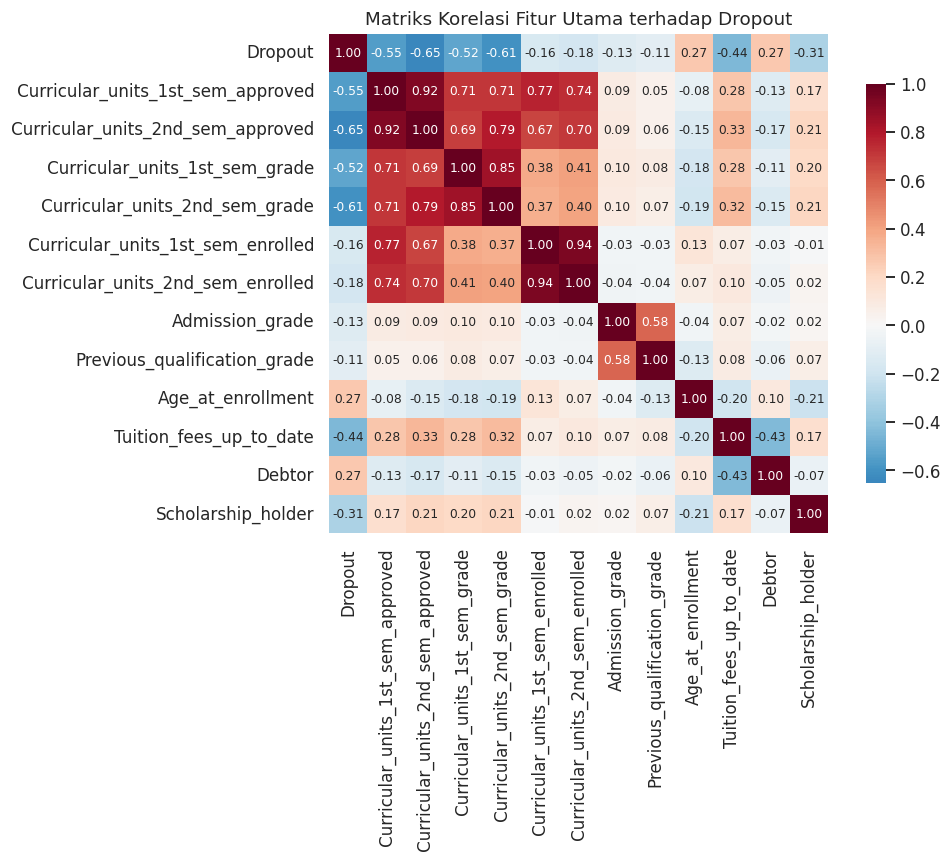

Curricular_units_2nd_sem_approved   -0.654
Curricular_units_2nd_sem_grade      -0.605
Curricular_units_1st_sem_approved   -0.555
Curricular_units_1st_sem_grade      -0.520
Tuition_fees_up_to_date             -0.442
Scholarship_holder                  -0.313
Curricular_units_2nd_sem_enrolled   -0.183
Curricular_units_1st_sem_enrolled   -0.161
Admission_grade                     -0.128
Previous_qualification_grade        -0.109
Debtor                               0.267
Age_at_enrollment                    0.267
Name: Dropout, dtype: float64

In [ ]:
num_corr = ["Dropout", "Curricular_units_1st_sem_approved", "Curricular_units_2nd_sem_approved",
            "Curricular_units_1st_sem_grade", "Curricular_units_2nd_sem_grade",
            "Curricular_units_1st_sem_enrolled", "Curricular_units_2nd_sem_enrolled",
            "Admission_grade", "Previous_qualification_grade", "Age_at_enrollment",
            "Tuition_fees_up_to_date", "Debtor", "Scholarship_holder"]
plt.figure(figsize=(10, 8))
sns.heatmap(model_df[num_corr].corr(), annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, cbar_kws={"shrink": .8}, annot_kws={"size": 8})
plt.title("Matriks Korelasi Fitur Utama terhadap Dropout")
plt.tight_layout(); plt.show()

model_df[num_corr].corr()["Dropout"].drop("Dropout").sort_values().round(3)

**Insight.** Korelasi terkuat dengan dropout dimiliki oleh `Curricular_units_2nd_sem_approved`
dan `Curricular_units_1st_sem_approved` — semakin banyak mata kuliah yang lulus, semakin kecil
risiko dropout. `Tuition_fees_up_to_date` juga berkorelasi kuat negatif.

Perlu dicatat bahwa fitur semester 1 dan 2 saling berkorelasi tinggi (multikolinearitas). Hal ini
tidak mengganggu model berbasis pohon, namun perlu diingat saat menafsirkan koefisien regresi
logistik.

### 4.1 Ringkasan Preprocessing

Setelah penyaringan kohort, langkah persiapan data selanjutnya:

1. **Split data** — 80% latih / 20% uji, *stratified* agar proporsi dropout terjaga pada kedua
   bagian.
2. **Preprocessing pipeline** — `StandardScaler` untuk 19 fitur numerik dan `OneHotEncoder`
   (`handle_unknown="ignore"`, `min_frequency=10`) untuk 17 fitur kategorikal. Seluruh transformasi
   dibungkus dalam `Pipeline` sehingga proses *fit* hanya terjadi pada data latih dan **tidak ada
   kebocoran data** ke data uji.

In [ ]:
X = model_df[CAT + NUM]
y = model_df["Dropout"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

print(f"Data latih : {X_train.shape} | dropout {y_train.mean()*100:.1f}%")
print(f"Data uji   : {X_test.shape} | dropout {y_test.mean()*100:.1f}%")

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), NUM),
    ("cat", OneHotEncoder(handle_unknown="ignore", min_frequency=10, sparse_output=False), CAT),
])
preprocessor.fit(X_train)
print("Jumlah fitur setelah encoding:", preprocessor.transform(X_train.head()).shape[1])

Data latih : (2904, 36) | dropout 39.2%
Data uji   : (726, 36) | dropout 39.1%
Jumlah fitur setelah encoding: 133


## 5. Modeling

Tiga algoritma dibandingkan, masing-masing dibungkus dalam pipeline yang sama:

| Model | Alasan dipilih |
|---|---|
| **Logistic Regression** | *Baseline* linier yang mudah diinterpretasi lewat odds ratio |
| **Random Forest** | Ensemble bagging, tahan outlier dan interaksi non-linier |
| **HistGradientBoosting** | Ensemble boosting, umumnya kuat untuk data tabular |

Evaluasi menggunakan **5-fold Stratified Cross Validation** pada data latih (ROC-AUC dan F1),
lalu diverifikasi pada data uji yang belum pernah dilihat model.

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(n_estimators=500, min_samples_leaf=2,
                                            class_weight="balanced_subsample",
                                            random_state=RANDOM_STATE, n_jobs=-1),
    "HistGradientBoosting": HistGradientBoostingClassifier(
        random_state=RANDOM_STATE, learning_rate=0.08, max_iter=400, max_leaf_nodes=31,
        l2_regularization=1.0, early_stopping=True, validation_fraction=0.15),
}

cv = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)
rows, fitted = [], {}

for name, m in models.items():
    pipe = Pipeline([("pre", preprocessor), ("clf", m)])
    auc_cv = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)
    f1_cv = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="f1", n_jobs=-1)
    pipe.fit(X_train, y_train)
    proba = pipe.predict_proba(X_test)[:, 1]
    pred = (proba >= 0.5).astype(int)
    rows.append({"Model": name,
                 "CV ROC-AUC": auc_cv.mean(), "CV F1": f1_cv.mean(),
                 "Accuracy": accuracy_score(y_test, pred),
                 "Precision": precision_score(y_test, pred),
                 "Recall": recall_score(y_test, pred),
                 "F1": f1_score(y_test, pred),
                 "ROC-AUC": roc_auc_score(y_test, proba),
                 "PR-AUC": average_precision_score(y_test, proba)})
    fitted[name] = pipe
    print(f"selesai: {name}")

comparison = pd.DataFrame(rows).round(4)
comparison

selesai: Logistic Regression


selesai: Random Forest


selesai: HistGradientBoosting


,Model,CV ROC-AUC,CV F1,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Logistic Regression,0.9455,0.8671,0.9201,0.8669,0.9401,0.9020,0.9753,0.9726
1,Random Forest,0.9459,0.8657,0.9256,0.9167,0.8908,0.9036,0.9724,0.9688
2,HistGradientBoosting,0.9442,0.8624,0.9229,0.9222,0.8768,0.8989,0.9682,0.9671


Ketiga model memberikan performa yang sangat berdekatan, namun **Logistic Regression** unggul
pada ROC-AUC uji (**0,9753**) dan PR-AUC (**0,9726**).

Menarik untuk dicatat: setelah target dibersihkan dari ambiguitas kelas `Enrolled`, batas antara
Dropout dan Graduate menjadi cukup jelas sehingga **model linier sederhana sudah memadai** dan
tidak kalah dari ensemble yang jauh lebih kompleks. Model ini juga dipilih karena lebih ringan
saat di-*deploy* dan koefisiennya dapat diterjemahkan langsung menjadi odds ratio.

In [ ]:
best_name = comparison.sort_values("ROC-AUC", ascending=False).iloc[0]["Model"]
best_model = fitted[best_name]
print("Model terbaik:", best_name)

Model terbaik: Logistic Regression


## 6. Evaluation

### 6.1 Penyetelan Threshold

Ambang default 0,5 belum tentu optimal. Dalam konteks bisnis, **false negative** (mahasiswa
berisiko yang lolos deteksi) lebih mahal daripada **false positive** (mahasiswa aman yang ikut
bimbingan tambahan). Threshold dicari dari **prediksi out-of-fold pada data latih** — bukan dari
data uji — agar tidak terjadi kebocoran informasi.

Perlu diperhatikan bahwa karena model memakai `class_weight="balanced"`, distribusi probabilitas
keluarannya bergeser ke atas, sehingga threshold optimalnya berada di atas 0,5.

In [ ]:
oof = cross_val_predict(Pipeline([("pre", preprocessor), ("clf", models[best_name])]),
                        X_train, y_train, cv=cv, method="predict_proba", n_jobs=-1)[:, 1]

prec, rec, thr = precision_recall_curve(y_train, oof)
f1s = 2 * prec * rec / (prec + rec + 1e-12)
THRESHOLD = float(thr[int(np.nanargmax(f1s[:-1]))])
print(f"Threshold optimal (dari OOF data latih): {THRESHOLD:.3f}")

proba_test = best_model.predict_proba(X_test)[:, 1]
tabel = []
for t in [0.40, 0.50, 0.60, THRESHOLD, 0.75, 0.85]:
    p = (proba_test >= t).astype(int)
    tabel.append({"Threshold": round(t, 3), "Accuracy": accuracy_score(y_test, p),
                  "Precision": precision_score(y_test, p), "Recall": recall_score(y_test, p),
                  "F1": f1_score(y_test, p)})
pd.DataFrame(tabel).round(4)

Threshold optimal (dari OOF data latih): 0.688


,Threshold,Accuracy,Precision,Recall,F1
0,0.400,0.8967,0.8157,0.9507,0.8780
1,0.500,0.9201,0.8669,0.9401,0.9020
2,0.600,0.9284,0.9000,0.9190,0.9094
3,0.688,0.9353,0.9373,0.8944,0.9153
4,0.750,0.9298,0.9533,0.8627,0.9057
5,0.850,0.9270,0.9753,0.8345,0.8994


              precision    recall  f1-score   support

    Graduate      0.934     0.962     0.948       442
     Dropout      0.937     0.894     0.915       284

    accuracy                          0.935       726
   macro avg      0.936     0.928     0.931       726
weighted avg      0.935     0.935     0.935       726



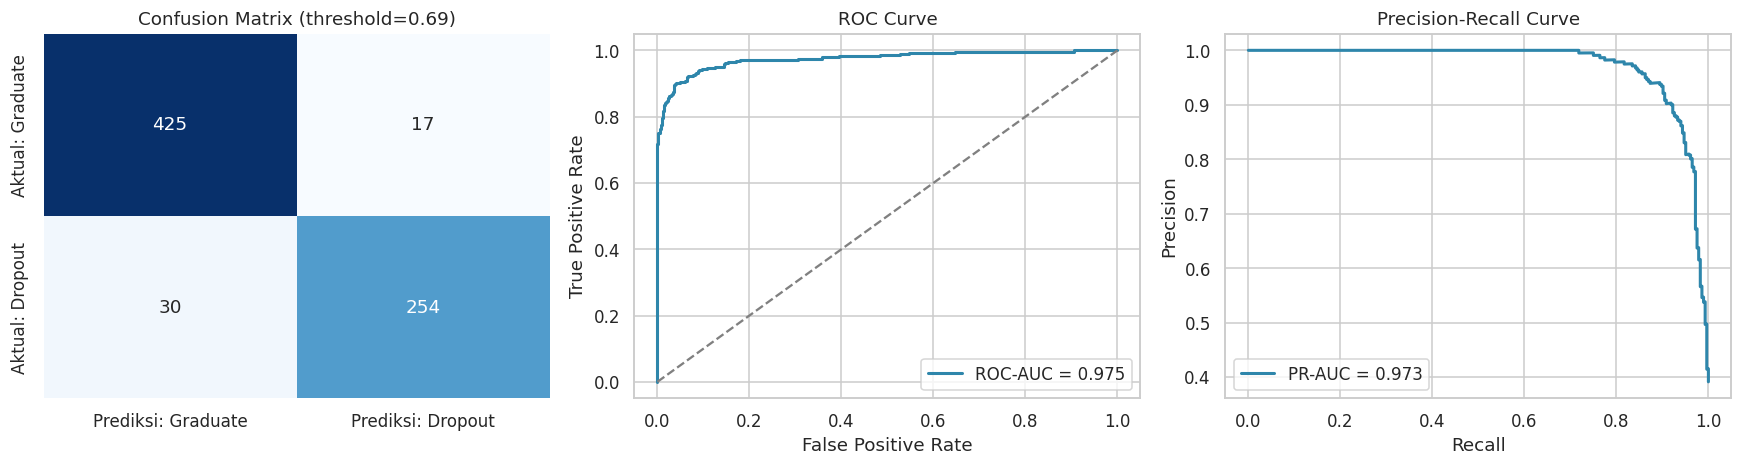

In [ ]:
y_pred = (proba_test >= THRESHOLD).astype(int)
print(classification_report(y_test, y_pred, target_names=["Graduate", "Dropout"], digits=3))

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(1, 3, figsize=(16, 4.4))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax[0],
            xticklabels=["Prediksi: Graduate", "Prediksi: Dropout"],
            yticklabels=["Aktual: Graduate", "Aktual: Dropout"])
ax[0].set_title(f"Confusion Matrix (threshold={THRESHOLD:.2f})")

fpr, tpr, _ = roc_curve(y_test, proba_test)
ax[1].plot(fpr, tpr, color=BLUE, lw=2, label=f"ROC-AUC = {roc_auc_score(y_test, proba_test):.3f}")
ax[1].plot([0, 1], [0, 1], "--", color="gray")
ax[1].set_xlabel("False Positive Rate"); ax[1].set_ylabel("True Positive Rate")
ax[1].set_title("ROC Curve"); ax[1].legend()

pr_, rc_, _ = precision_recall_curve(y_test, proba_test)
ax[2].plot(rc_, pr_, color=BLUE, lw=2,
           label=f"PR-AUC = {average_precision_score(y_test, proba_test):.3f}")
ax[2].set_xlabel("Recall"); ax[2].set_ylabel("Precision")
ax[2].set_title("Precision-Recall Curve"); ax[2].legend()
plt.tight_layout(); plt.show()

### 6.2 Interpretasi Hasil Evaluasi

Pada threshold **0,688**, model mencapai:

| Metrik | Nilai | Arti bisnis |
|---|---|---|
| Accuracy | **0,935** | Sekitar 94 dari 100 prediksi benar |
| Recall (Dropout) | **0,894** | Hampir 9 dari 10 calon dropout terdeteksi lebih awal |
| Precision (Dropout) | **0,937** | 94% mahasiswa yang ditandai memang benar berisiko |
| F1-Score (Dropout) | **0,915** | Keseimbangan precision dan recall sangat baik |
| ROC-AUC | **0,975** | Kemampuan pemisahan kelas sangat baik |
| PR-AUC | **0,973** | Tetap andal pada kelas positif |

Dari confusion matrix, dari **284 mahasiswa dropout** pada data uji, **254 berhasil terdeteksi**
dan hanya **30 yang lolos**. Sementara *false positive* sebanyak **17 orang** — biaya kesalahan
ini rendah, karena konsekuensinya hanya berupa bimbingan tambahan bagi mahasiswa yang sebenarnya
aman.

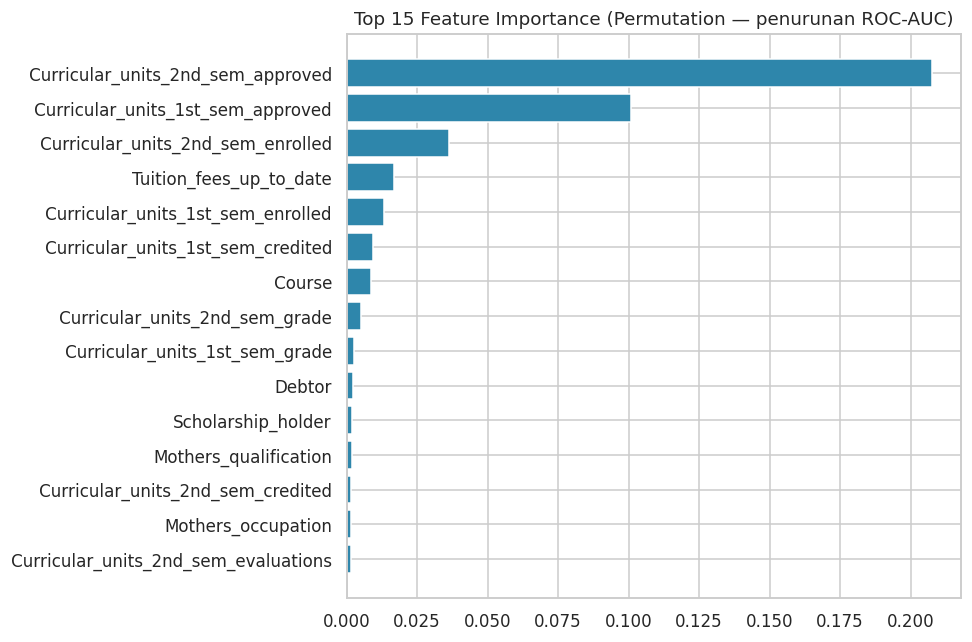

,Fitur,Importance
0,Curricular_units_2nd_sem_approved,0.207638
1,Curricular_units_1st_sem_approved,0.100781
2,Curricular_units_2nd_sem_enrolled,0.036179
3,Tuition_fees_up_to_date,0.017004
4,Curricular_units_1st_sem_enrolled,0.013149
5,Curricular_units_1st_sem_credited,0.009491
6,Course,0.008836
7,Curricular_units_2nd_sem_grade,0.005311
8,Curricular_units_1st_sem_grade,0.002822
9,Debtor,0.002406


In [ ]:
perm = permutation_importance(best_model, X_test, y_test, n_repeats=10,
                              random_state=RANDOM_STATE, scoring="roc_auc", n_jobs=-1)
importance = (pd.DataFrame({"Fitur": X.columns, "Importance": perm.importances_mean})
              .sort_values("Importance", ascending=False).reset_index(drop=True))

top = importance.head(15).iloc[::-1]
plt.figure(figsize=(9, 6))
plt.barh(top["Fitur"], top["Importance"], color=BLUE)
plt.title("Top 15 Feature Importance (Permutation — penurunan ROC-AUC)")
plt.tight_layout(); plt.show()
importance.head(10)

### 6.3 Faktor Penentu Dropout

Hasil *permutation importance* menegaskan temuan EDA:

1. **`Curricular_units_2nd_sem_approved`** — jumlah mata kuliah lulus di semester 2 adalah
   prediktor terkuat, dengan jarak yang sangat lebar dari fitur lainnya.
2. **`Curricular_units_1st_sem_approved`** — performa semester 1 menyusul di posisi kedua.
3. **`Curricular_units_2nd_sem_enrolled`**, **`Tuition_fees_up_to_date`**, dan **`Course`**
   melengkapi lima besar.

Implikasinya: institusi tidak perlu menunggu hingga akhir masa studi. **Cukup dengan data akhir
semester 2 ditambah status pembayaran, risiko dropout sudah dapat diprediksi secara akurat.**

## 7. Menyimpan Artefak Model

Model final dilatih ulang pada **seluruh kohort pemodelan** (3.630 mahasiswa) agar memanfaatkan
semua informasi yang tersedia, kemudian disimpan bersama nilai threshold dan daftar fitur.

In [ ]:
os.makedirs("model", exist_ok=True)

final_model = Pipeline([("pre", preprocessor), ("clf", models[best_name])])
final_model.fit(X, y)

joblib.dump({"pipeline": final_model, "threshold": round(THRESHOLD, 3),
             "cat": CAT, "num": NUM, "model_name": "LogisticRegression"},
            "model/dropout_model.joblib")

defaults = {c: int(model_df[c].mode()[0]) for c in CAT}
defaults.update({c: float(model_df[c].median()) for c in NUM})
json.dump(defaults, open("model/defaults.json", "w"), indent=2)

print("Artefak tersimpan di folder model/")

Artefak tersimpan di folder model/


In [ ]:
# Uji cepat artefak yang tersimpan
bundle = joblib.load("model/dropout_model.joblib")
FEATURES = bundle["cat"] + bundle["num"]

skenario = {
    "Mahasiswa berisiko": {"Curricular_units_1st_sem_approved": 0,
                           "Curricular_units_2nd_sem_approved": 0,
                           "Tuition_fees_up_to_date": 0, "Debtor": 1, "Age_at_enrollment": 30},
    "Mahasiswa aman": {"Curricular_units_1st_sem_approved": 6,
                       "Curricular_units_2nd_sem_approved": 6,
                       "Curricular_units_2nd_sem_grade": 14.0,
                       "Tuition_fees_up_to_date": 1, "Scholarship_holder": 1,
                       "Age_at_enrollment": 19},
}
for nama, nilai in skenario.items():
    frame = pd.DataFrame([{**defaults, **nilai}])[FEATURES]
    p = bundle["pipeline"].predict_proba(frame)[0, 1]
    print(f"{nama:20s} -> skor risiko {p*100:5.1f}%")

Mahasiswa berisiko   -> skor risiko 100.0%
Mahasiswa aman       -> skor risiko   2.9%


## 8. Penerapan Model pada Mahasiswa Aktif (Enrolled)

Inilah kegunaan sesungguhnya dari kohort `Enrolled` yang tadi disimpan terpisah. Ke-794 mahasiswa
yang masih berjalan **tidak dipakai untuk melatih model**, melainkan menjadi **sasaran prediksi**
— persis seperti cara sistem ini akan dipakai di dunia nyata pada setiap akhir semester.

Distribusi risiko 794 mahasiswa aktif:
Level_Risiko
Rendah    252
Sedang    187
Tinggi    355
Name: count, dtype: int64

Perlu intervensi segera (Risiko Tinggi): 355 mahasiswa (44.7%)


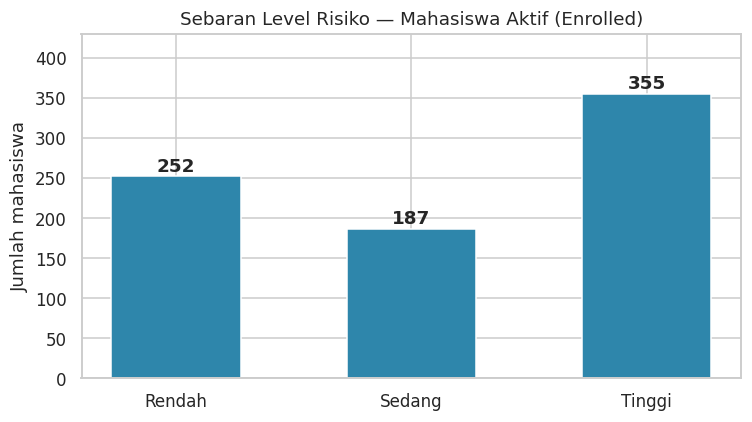

In [ ]:
enr_proba = final_model.predict_proba(enrolled_df[CAT + NUM])[:, 1]
enrolled_df["Skor_Risiko"] = (enr_proba * 100).round(1)
enrolled_df["Level_Risiko"] = pd.cut(enrolled_df["Skor_Risiko"], [-1, 30, 60, 100],
                                     labels=["Rendah", "Sedang", "Tinggi"])

ringkas = enrolled_df["Level_Risiko"].value_counts().reindex(["Rendah", "Sedang", "Tinggi"])
print("Distribusi risiko 794 mahasiswa aktif:")
print(ringkas)
print(f"\nPerlu intervensi segera (Risiko Tinggi): {ringkas['Tinggi']} mahasiswa "
      f"({ringkas['Tinggi']/len(enrolled_df)*100:.1f}%)")

plt.figure(figsize=(7, 4))
plt.bar(ringkas.index.astype(str), ringkas.values, color=BLUE, width=0.55)
for i, v in enumerate(ringkas.values):
    plt.text(i, v + 6, f"{v}", ha="center", fontweight="bold")
plt.title("Sebaran Level Risiko — Mahasiswa Aktif (Enrolled)")
plt.ylabel("Jumlah mahasiswa"); plt.ylim(0, 430); plt.tight_layout(); plt.show()

**Temuan operasional.** Dari 794 mahasiswa yang masih aktif, **355 orang (44,7%) tergolong Risiko
Tinggi** dan perlu segera masuk program bimbingan khusus. Inilah daftar kerja konkret yang bisa
langsung diserahkan ke bagian kemahasiswaan besok pagi — sesuatu yang sebelumnya tidak mungkin
dihasilkan institusi.

## 9. Menyiapkan Dataset untuk Business Dashboard

Kode kategorikal diterjemahkan menjadi label yang dapat dibaca manusia, dan ditambahkan kolom
turunan (`Approval_Rate`, `Kategori_Performa`, `Skor_Risiko`, `Level_Risiko`, `Kohort`).

Dua catatan penting:

- **Skor risiko kohort selesai** dihitung memakai **prediksi out-of-fold**, agar nilainya jujur
  dan tidak *overfit* pada data yang sama.
- **Kolom `Is_Dropout` sengaja dikosongkan** untuk mahasiswa `Enrolled`, sehingga saat dashboard
  menghitung rata-rata dropout rate, kelompok yang belum diketahui hasil akhirnya **tidak ikut
  mengencerkan angka**. Kolom `Kohort` disediakan agar dashboard tetap dapat memfilter keduanya.

In [ ]:
MARITAL = {1: "Single", 2: "Married", 3: "Widower", 4: "Divorced",
           5: "Facto Union", 6: "Legally Separated"}
APPMODE = {1: "1st phase - general", 2: "Ordinance 612/93", 5: "1st phase - Azores",
           7: "Holder of other higher course", 10: "Ordinance 854-B/99",
           15: "International student", 16: "1st phase - Madeira", 17: "2nd phase - general",
           18: "3rd phase - general", 26: "Different Plan", 27: "Other Institution",
           39: "Over 23 years old", 42: "Transfer", 43: "Change of course",
           44: "Tech. specialization holder", 51: "Change of institution/course",
           53: "Short cycle holder", 57: "Change of institution (Intl)"}

# skor risiko out-of-fold untuk kohort yang telah selesai
oof_full = cross_val_predict(Pipeline([("pre", preprocessor), ("clf", models[best_name])]),
                            X, y, cv=cv, method="predict_proba", n_jobs=-1)[:, 1]

sel = model_df.copy()
sel["Skor_Risiko"] = (oof_full * 100).round(1)
enr = enrolled_df.copy()
enr["Dropout"] = np.nan

d = pd.concat([sel, enr], ignore_index=True).sort_index()
d.insert(0, "Student_ID", ["STD-" + str(i).zfill(4) for i in range(1, len(d) + 1)])
d["Program_Studi"] = d["Course"].map(COURSE).fillna("Lainnya")
d["Status_Pernikahan"] = d["Marital_status"].map(MARITAL).fillna("Lainnya")
d["Jalur_Masuk"] = d["Application_mode"].map(APPMODE).fillna("Lainnya")
d["Gender_Label"] = d["Gender"].map({1: "Laki-laki", 0: "Perempuan"})
d["Kelas"] = d["Daytime_evening_attendance"].map({1: "Reguler (Siang)", 0: "Kelas Malam"})
for c, lab in [("Debtor", ("Tidak", "Ya")), ("Tuition_fees_up_to_date", ("Menunggak", "Lunas")),
               ("Scholarship_holder", ("Tidak", "Ya")), ("Displaced", ("Tidak", "Ya")),
               ("Educational_special_needs", ("Tidak", "Ya")),
               ("International", ("Domestik", "Internasional"))]:
    d[c + "_Label"] = d[c].map({0: lab[0], 1: lab[1]})
d["Kelompok_Usia"] = pd.cut(d["Age_at_enrollment"], [0, 20, 23, 27, 35, 100],
                            labels=["<=20", "21-23", "24-27", "28-35", ">35"])
tot_d = d["Curricular_units_1st_sem_enrolled"] + d["Curricular_units_2nd_sem_enrolled"]
apr_d = d["Curricular_units_1st_sem_approved"] + d["Curricular_units_2nd_sem_approved"]
d["Approval_Rate"] = np.where(tot_d > 0, (apr_d / tot_d * 100).round(1), 0)
d["Rata_Nilai"] = ((d["Curricular_units_1st_sem_grade"] +
                    d["Curricular_units_2nd_sem_grade"]) / 2).round(2)
d["Kategori_Performa"] = pd.cut(d["Approval_Rate"], [-1, 25, 50, 75, 100],
                                labels=["Kritis (<25%)", "Rendah (25-50%)",
                                        "Sedang (50-75%)", "Baik (>75%)"])
d["Is_Dropout"] = d["Dropout"]
d["Kohort"] = np.where(d["Status"] == "Enrolled", "Masih Aktif", "Telah Selesai")
d["Level_Risiko"] = pd.cut(d["Skor_Risiko"], [-1, 30, 60, 100],
                           labels=["Rendah", "Sedang", "Tinggi"])

keep = ["Student_ID", "Status", "Kohort", "Is_Dropout", "Skor_Risiko", "Level_Risiko",
        "Program_Studi", "Jalur_Masuk", "Kelas", "Gender_Label", "Kelompok_Usia",
        "Age_at_enrollment", "Status_Pernikahan", "Debtor_Label",
        "Tuition_fees_up_to_date_Label", "Scholarship_holder_Label", "Displaced_Label",
        "Educational_special_needs_Label", "International_Label", "Admission_grade",
        "Previous_qualification_grade", "Curricular_units_1st_sem_enrolled",
        "Curricular_units_1st_sem_approved", "Curricular_units_1st_sem_grade",
        "Curricular_units_2nd_sem_enrolled", "Curricular_units_2nd_sem_approved",
        "Curricular_units_2nd_sem_grade", "Approval_Rate", "Rata_Nilai", "Kategori_Performa",
        "Unemployment_rate", "Inflation_rate", "GDP"]

os.makedirs("dashboard", exist_ok=True)
dash = d[keep]
dash.to_csv("dashboard/students_dashboard.csv", index=False)

# berkas terpisah berisi daftar prioritas mahasiswa aktif
dash[dash["Kohort"] == "Masih Aktif"].sort_values("Skor_Risiko", ascending=False) \
    .to_csv("dashboard/enrolled_prediksi.csv", index=False)

print("Dimensi dataset dashboard:", dash.shape)
dash.head()

Dimensi dataset dashboard: (4424, 33)


,Student_ID,Status,Kohort,Is_Dropout,Skor_Risiko,Level_Risiko,Program_Studi,Jalur_Masuk,Kelas,Gender_Label,...,Curricular_units_1st_sem_grade,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Approval_Rate,Rata_Nilai,Kategori_Performa,Unemployment_rate,Inflation_rate,GDP
0,STD-0001,Dropout,Telah Selesai,1.0,65.9,Tinggi,Animation & Multimedia,2nd phase - general,Reguler (Siang),Laki-laki,...,0.000000,0,0,0.000000,0.0,0.00,Kritis (<25%),10.8,1.4,1.74
1,STD-0002,Graduate,Telah Selesai,0.0,40.1,Sedang,Tourism,International student,Reguler (Siang),Laki-laki,...,14.000000,6,6,13.666667,100.0,13.83,Baik (>75%),13.9,-0.3,0.79
2,STD-0003,Dropout,Telah Selesai,1.0,100.0,Tinggi,Communication Design,1st phase - general,Reguler (Siang),Laki-laki,...,0.000000,6,0,0.000000,0.0,0.00,Kritis (<25%),10.8,1.4,1.74
3,STD-0004,Graduate,Telah Selesai,0.0,28.1,Rendah,Journalism & Comm,2nd phase - general,Reguler (Siang),Perempuan,...,13.428571,6,5,12.400000,91.7,12.91,Baik (>75%),9.4,-0.8,-3.12
4,STD-0005,Graduate,Telah Selesai,0.0,9.1,Rendah,Social Service (eve),Over 23 years old,Kelas Malam,Perempuan,...,12.333333,6,6,13.000000,91.7,12.67,Baik (>75%),13.9,-0.3,0.79


In [ ]:
# Validasi kalibrasi level risiko (hanya pada kohort yang hasil akhirnya sudah diketahui)
selesai = dash[dash["Kohort"] == "Telah Selesai"]
cek = selesai.groupby("Level_Risiko", observed=True)["Is_Dropout"].agg(
    Jumlah_Mahasiswa="count", Dropout_Rate_Aktual="mean")
cek["Dropout_Rate_Aktual"] = (cek["Dropout_Rate_Aktual"] * 100).round(1)
cek

,Jumlah_Mahasiswa,Dropout_Rate_Aktual
Level_Risiko,,
Rendah,2008,6.0
Sedang,322,32.0
Tinggi,1300,92.2


**Validasi.** Level risiko yang dihasilkan model terkalibrasi dengan sangat baik: kelompok
**Risiko Tinggi memiliki dropout rate aktual 92,2%**, **Sedang 32,0%**, dan **Rendah hanya 6,0%**.
Dengan demikian daftar prioritas yang muncul di dashboard benar-benar dapat dipercaya oleh bagian
kemahasiswaan.

## 10. Conclusion

Proyek ini berhasil menjawab keempat permasalahan bisnis Jaya Jaya Institut.

**1. Skala dan sebaran masalah kini terpetakan.**
Dari 4.424 mahasiswa, sebanyak **3.630 telah menyelesaikan masa studinya** dan **1.421 di
antaranya dropout** — setara **39,1%** dari kohort tersebut. Masalah ini tidak merata, melainkan
terkonsentrasi pada program studi tertentu: **Biofuel Production Technologies (88,9%)**,
**Informatics Engineering (86,8%)**, **Equinculture (65,0%)**, **Management kelas malam (63,6%)**,
dan **Basic Education (59,9%)**. Sebaliknya **Nursing (17,7%)** merupakan yang paling aman.
Dropout rate juga meningkat tajam seiring usia pendaftaran, dari **26,1%** pada kelompok ≤20 tahun
menjadi **66,4%** pada kelompok 28–35 tahun.

**2. Faktor penentu dropout telah teridentifikasi.**
Hasil EDA dan permutation importance secara konsisten menunjuk dua kelompok faktor dominan:

- **Performa akademik dua semester pertama.** Jumlah mata kuliah yang lulus pada semester 2 adalah
  prediktor tunggal terkuat, disusul semester 1. Mahasiswa dengan tingkat kelulusan mata kuliah
  **di atas 75%** hanya dropout **9,5%**, sedangkan seluruh kelompok di bawah ambang itu berada
  pada **67,7% hingga 98,7%**.
- **Kondisi finansial.** Mahasiswa yang **menunggak UKT** dropout pada tingkat **94,0%** dibanding
  **30,7%** pada yang lunas. Mahasiswa berstatus **debitur** dropout **75,5%**, sedangkan
  **penerima beasiswa** jauh lebih aman dengan hanya **13,8%**.

Temuan paling penting justru terletak pada apa yang **tidak** berpengaruh: nilai ujian masuk
hampir tidak membedakan kelompok dropout (**124,96**) dan lulusan (**128,79**). Artinya, **dropout
di Jaya Jaya Institut bukan masalah kualitas seleksi calon mahasiswa, melainkan masalah dukungan
selama masa studi** — terutama dukungan finansial dan pendampingan akademik.

**3. Sistem deteksi dini telah tersedia dan terbukti akurat.**
Model **Logistic Regression** mencapai **ROC-AUC 0,975**, **akurasi 93,5%**, **precision 93,7%**,
dan **recall 89,4%** pada data uji. Dari 284 mahasiswa dropout pada data uji, **254 berhasil
terdeteksi lebih awal** dan hanya 30 yang lolos. Level risiko yang dihasilkan juga terkalibrasi
dengan baik: kelompok **Risiko Tinggi memiliki dropout rate aktual 92,2%**, Sedang 32,0%, dan
Rendah 6,0%. Karena prediktor utamanya adalah data akhir semester 2, deteksi dapat dilakukan
**sejak tahun pertama**, memberi institusi waktu intervensi yang memadai.

**4. Alat monitoring telah dibangun.**
Business dashboard dan prototype Streamlit memungkinkan manajemen memantau performa siswa serta
menghasilkan daftar prioritas intervensi secara mandiri, tanpa perlu menjalankan kode.

**Dampak yang langsung dapat dieksekusi.** Ketika model diterapkan pada **794 mahasiswa yang masih
aktif**, teridentifikasi **355 mahasiswa (44,7%) berisiko tinggi** yang perlu segera mendapat
bimbingan khusus. Dengan recall 89,4%, sekitar **317 di antaranya benar-benar akan dropout** bila
tidak ada intervensi. Apabila program bimbingan berhasil menyelamatkan 30% saja dari kelompok
tersebut, institusi mempertahankan sekitar **95 mahasiswa** hanya dari satu siklus prediksi.

## 11. Rekomendasi Action Items

**1. Terapkan sistem deteksi dini di akhir setiap semester.**
Jalankan prediksi massal terhadap seluruh mahasiswa aktif setiap akhir semester menggunakan
prototype Streamlit, lalu terbitkan daftar prioritas berdasarkan skor risiko. Mulai dari **355
mahasiswa Risiko Tinggi** yang sudah teridentifikasi pada berkas `enrolled_prediksi.csv`. Tetapkan
satu dosen wali sebagai penanggung jawab untuk setiap 10 mahasiswa berisiko tinggi.

**2. Jadikan keringanan biaya sebagai intervensi prioritas utama.**
Karena tunggakan UKT berasosiasi dengan dropout rate **94,0%** — praktis sebuah vonis — sediakan
skema cicilan fleksibel, penundaan pembayaran, atau dana talangan darurat. Lakukan **kontak
proaktif** kepada setiap mahasiswa yang tunggakannya melewati 30 hari, jangan menunggu mahasiswa
mengajukan sendiri.

**3. Perluas dan targetkan ulang alokasi beasiswa.**
Penerima beasiswa hanya dropout 13,8% dibanding 48,4% pada non-penerima. Prioritaskan alokasi
beasiswa bagi mahasiswa berskor risiko tinggi yang masih menunjukkan potensi akademik, dan
naikkan kuota khusus untuk program studi dengan dropout rate tertinggi.

**4. Terapkan aturan pemicu akademik otomatis (*academic trigger*).**
Tetapkan aturan sederhana yang dapat dijalankan dosen wali tanpa bantuan model: mahasiswa dengan
tingkat kelulusan mata kuliah **di bawah 75%** pada semester berjalan otomatis dijadwalkan
konseling akademik, program remedial, dan peninjauan ulang beban SKS. Ambang ini dipilih karena
di bawahnya risiko dropout melonjak dari 9,5% menjadi di atas 67%.

**5. Audit program studi berisiko tinggi.**
Lakukan evaluasi menyeluruh terhadap kurikulum, beban studi, kualitas pengajaran, dan fasilitas
pada **Biofuel Production Technologies (88,9%)** dan **Informatics Engineering (86,8%)**. Angka
setinggi ini mengindikasikan masalah struktural pada program, bukan sekadar kumpulan masalah
individual mahasiswa.

**6. Rancang dukungan khusus bagi mahasiswa non-tradisional.**
Mahasiswa yang mendaftar pada usia di atas 24 tahun, masuk melalui jalur *"Over 23 years old"*,
atau mengambil kelas malam menunjukkan risiko jauh lebih tinggi (di atas 60%). Sediakan kelas
hybrid, jadwal fleksibel, layanan penitipan anak, dan pendampingan manajemen waktu.

**7. Jadikan dashboard basis rapat evaluasi rutin, dan perbarui model setiap tahun.**
Tetapkan rapat evaluasi bulanan berbasis dashboard dengan tiga indikator utama: jumlah mahasiswa
aktif Risiko Tinggi, dropout rate per program studi, dan proporsi tunggakan UKT. Latih ulang model
setiap tahun ajaran menggunakan data terbaru — termasuk mahasiswa `Enrolled` yang statusnya sudah
final — agar performanya tetap terjaga.